# Simulated Anealing - Real-World Semiconductor Workshop Scheduling

In this notebook we will solve a real world scheduling problem using trajectory based **Simulated Anealing**.

## Algorithm

We have our main trajectory based Algorithm there.
Our main component:
* ...
* ...

In [ ]:
import math
import random
import sys
from typing import Dict, List, Tuple

import numpy as np

sys.path.append('../data-structure')
from individual import Individual
from instance_data import InstanceData


class SimulatedAnnealingScheduler:
    def __init__(self, instance: InstanceData, seed: int | None = None):
        self.instance = instance
        self.rng = np.random.default_rng(seed)

    def init_solution(self) -> Individual:
        m = self.instance.json_data["m"]
        n = self.instance.json_data["n"]
        capable = self.instance.json_data["capable"]

        scheduling = [[] for _ in range(m)]
        for job_id in range(n):
            machine_id = int(self.rng.choice(capable[job_id]))
            scheduling[machine_id].append(job_id)

        for machine_jobs in scheduling:
            self.rng.shuffle(machine_jobs)

        return Individual(scheduling)

    def evaluate(self, individual: Individual) -> float:
        release = self.instance.json_data["release"]
        duration = self.instance.json_data["duration"]
        setup = self.instance.json_data["setup"]

        makespan = 0.0
        for machine_id, machine_jobs in enumerate(individual.scheduling):
            machine_time = 0.0
            prev_job = None

            for job_id in machine_jobs:
                rel = release[job_id][machine_id]
                if prev_job is None:
                    start = max(machine_time, rel)
                else:
                    stp = setup[prev_job][job_id][machine_id]
                    start = max(rel, machine_time + stp)

                machine_time = start + duration[job_id][machine_id]
                prev_job = job_id

            makespan = max(makespan, machine_time)

        return makespan

    def neighbor(self, individual: Individual) -> Individual:
        capable = self.instance.json_data["capable"]
        candidate = individual.copy()
        m = len(candidate.scheduling)

        operation = "swap" if self.rng.random() < 0.5 else "move"

        if operation == "swap":
            machines_with_2 = [k for k in range(m) if len(candidate.scheduling[k]) >= 2]
            if machines_with_2:
                k = int(self.rng.choice(machines_with_2))
                i, j = self.rng.choice(len(candidate.scheduling[k]), size=2, replace=False)
                i, j = int(i), int(j)
                candidate.scheduling[k][i], candidate.scheduling[k][j] = (
                    candidate.scheduling[k][j],
                    candidate.scheduling[k][i],
                )
                return candidate

        non_empty = [k for k in range(m) if candidate.scheduling[k]]
        if not non_empty:
            return candidate

        src = int(self.rng.choice(non_empty))
        pos = int(self.rng.integers(0, len(candidate.scheduling[src])))
        job_id = candidate.scheduling[src].pop(pos)

        feasible_targets = capable[job_id]
        dst = int(self.rng.choice(feasible_targets))

        insert_pos = int(self.rng.integers(0, len(candidate.scheduling[dst]) + 1))
        candidate.scheduling[dst].insert(insert_pos, job_id)

        return candidate

    def solve(
        self,
        initial_temp: float = 600.0,
        cooling_rate: float = 0.95,
        min_temp: float = 1.0,
        iterations_per_temp: int = 200,
    ) -> Tuple[Dict, List[Tuple[int, float, float]]]:
        current = self.init_solution()
        current_score = self.evaluate(current)

        best = current.copy()
        best_score = current_score

        temperature = float(initial_temp)
        step = 0
        history: List[Tuple[int, float, float]] = []

        while temperature > min_temp:
            for _ in range(iterations_per_temp):
                step += 1

                candidate = self.neighbor(current)
                candidate_score = self.evaluate(candidate)
                delta = candidate_score - current_score

                # Accept always if better, maybe accept worse based on Boltzmann probability
                if delta <= 0 or self.rng.random() < math.exp(-delta / max(temperature, 1e-12)):
                    current = candidate
                    current_score = candidate_score

                    if current_score < best_score:
                        best = current.copy()
                        best_score = current_score

                history.append((step, best_score, temperature))

            temperature *= cooling_rate

        return best.format_solution(best_score), history

Best solution found: {'makespan': 1049, 'schedule': {'0': [5], '1': [], '2': [2, 3, 1, 4]}}
(True, 1049)


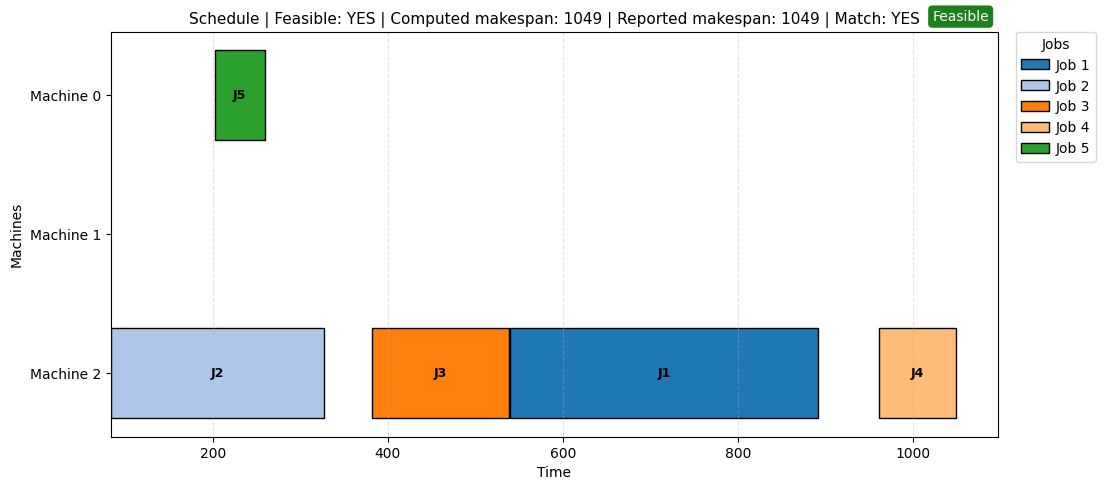

{'feasible': True,
 'checker_result': 1049,
 'reported_makespan': 1049,
 'computed_makespan': 1049}

In [15]:
import sys

sys.path.append('..')
from checker import check_and_evaluate
from scheduler_plot import plot_schedule_from_json

instance = InstanceData('../examples/75_3_5_H.json')
sa = SimulatedAnnealingScheduler(instance, seed=42)

best_solution, progress_history = sa.solve(
    initial_temp=600.0,
    cooling_rate=0.95,
    min_temp=1.0,
    iterations_per_temp=200,
)

print(f"Best solution found: {best_solution}")
print(check_and_evaluate(instance.json_data, best_solution))

plot_schedule_from_json(instance_path=instance.json_data, solution_path=best_solution)

Best solution found for hard instance: {'makespan': 8886, 'schedule': {'0': [7, 26, 37, 55, 17, 139, 15, 67, 10, 77], '1': [], '2': [], '3': [51], '4': [118], '5': [59, 74, 138, 137, 41, 23, 29], '6': [], '7': [108, 85, 25, 48, 75, 14], '8': [86], '9': [124], '10': [83, 11, 81, 92, 5, 42, 82, 9, 80, 60, 1, 145, 130, 36, 47, 46, 116, 56, 96, 121, 71, 110, 32, 31, 38, 87, 22, 13, 64, 143, 69, 104, 24, 54, 73, 63], '11': [109], '12': [21, 43, 12, 94, 129, 30, 95, 111, 140, 72, 79, 68, 44, 133, 115, 114, 50, 105, 102, 93, 28, 101, 2, 120, 45, 39, 35, 98, 65, 61, 33, 6, 49, 131, 122, 40, 119, 144, 103], '13': [99, 125, 20, 52, 146, 100, 142, 70, 90, 113, 4, 134, 141, 106, 107, 57, 117, 127, 76, 78, 34, 27, 135, 58, 97, 66, 112, 136, 18, 3, 62, 91, 88, 123, 89, 126, 8, 128, 132, 16, 53, 84], '14': [19]}}
(True, 8886)


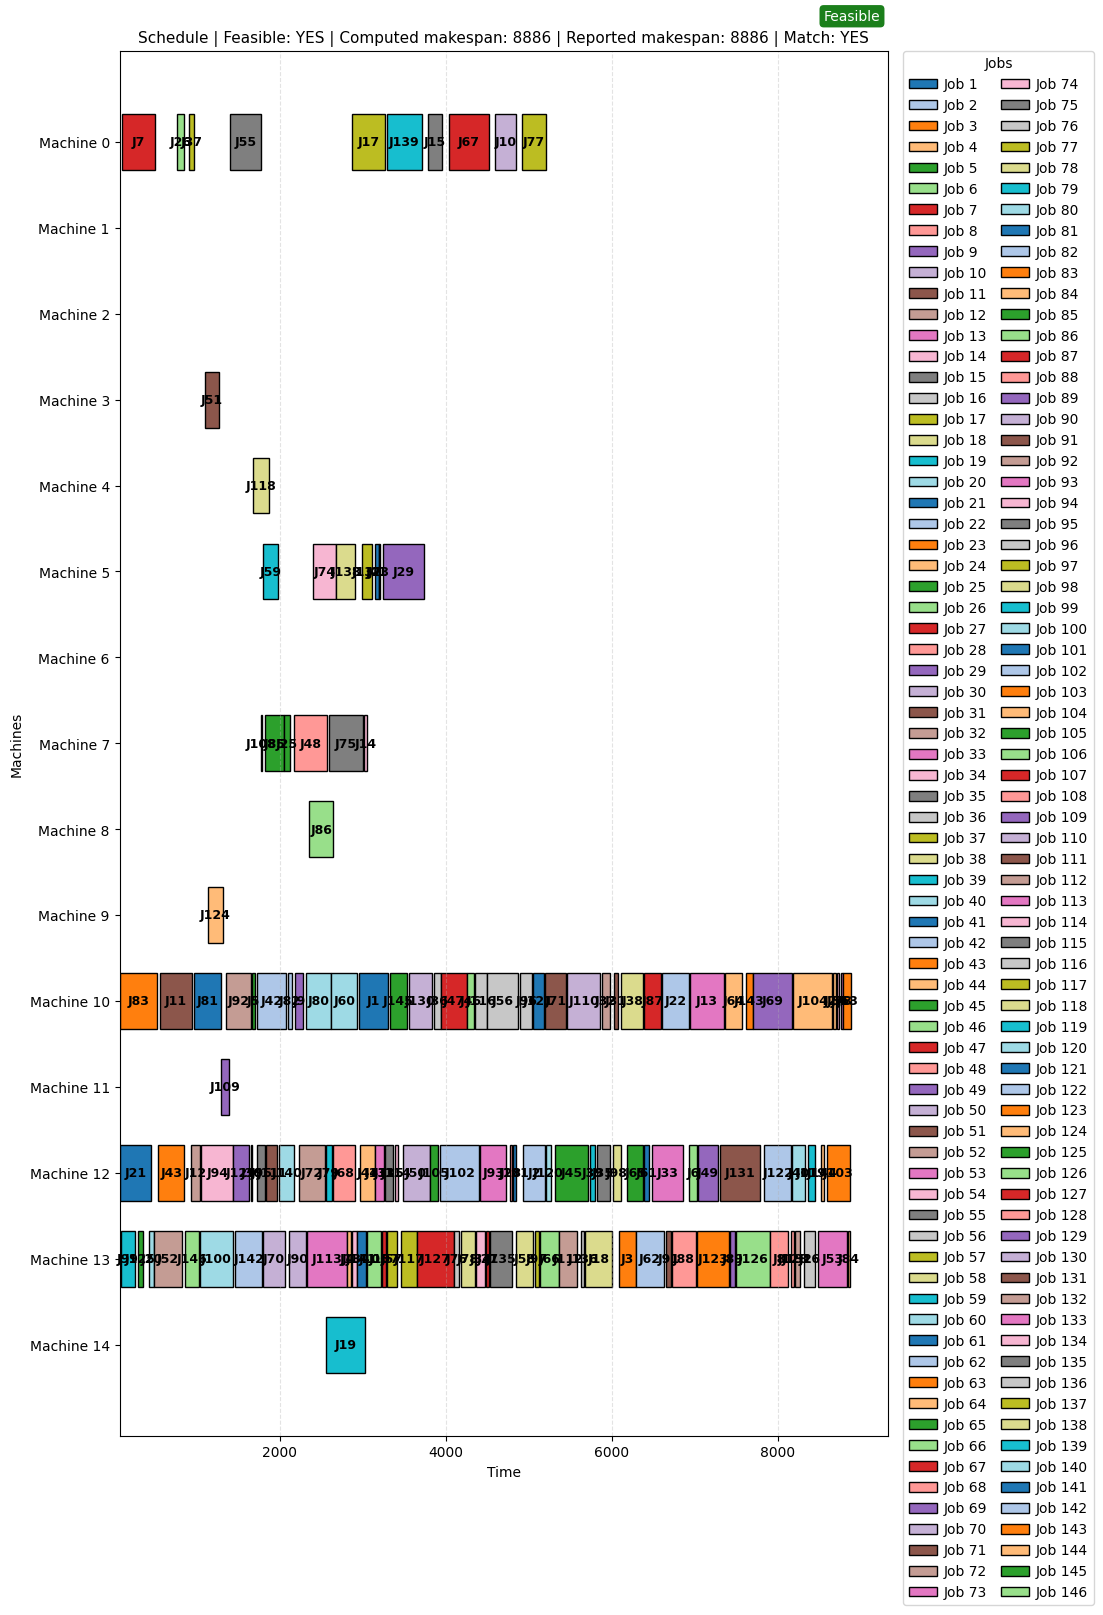

{'feasible': True,
 'checker_result': 8886,
 'reported_makespan': 8886,
 'computed_makespan': 8886}

In [16]:
hard_instance = InstanceData('../examples/357_15_146_H.json')
sa_hard = SimulatedAnnealingScheduler(hard_instance, seed=42)

best_solution_hard, progress_history_hard = sa_hard.solve(
    initial_temp=1200.0,
    cooling_rate=0.96,
    min_temp=2.0,
    iterations_per_temp=300,
)

print(f"Best solution found for hard instance: {best_solution_hard}")
print(check_and_evaluate(hard_instance.json_data, best_solution_hard))

plot_schedule_from_json(instance_path=hard_instance.json_data, solution_path=best_solution_hard)